In [182]:
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [183]:
file = uproot.open("build/yz.root")

print(file.keys()) 
tree = file["yz"]
df = tree.arrays(library="pd")

['yz;1']


### STEP 1
Plottare tutte e quantità del file

In [184]:
custom_ranges = {
    'radius': None,
    'nbHits': None,
    'nbScoredHits': None,
    'y': None,
    'z': None,
    'Einc': (-0.02, 0.02)
}

cols_to_plot = ['radius', 'nbHits', 'nbScoredHits', 'y', 'z', 'Einc']

units = {
    'radius': ' [nm]',
    'nbHits': '',
    'nbScoredHits': '',
    'y': ' [keV/um]',
    'z': ' [Gy]',
    'Einc': ' [MeV]'
} # Controlla se sto facendo bene...!

count = len(df)
# Senza [1:], includi TUTTI gli indici trovati
counts = df['nbScoredHits'].value_counts().sort_index()

n_zeros = (df['nbScoredHits'] == 0).sum()
print(f"Number of events with nbEdep = 0: {n_zeros}")

for i, count in counts.items():
    print(f"Number of events with nbEdep = {int(i)}: {int(count)}")

# Somma totale di tutto quello che hai trovato
print(f"Total of number of Event = {counts.sum()}")

Number of events with nbEdep = 0: 0
Number of events with nbEdep = 1: 1594
Number of events with nbEdep = 2: 1109
Number of events with nbEdep = 3: 1202
Number of events with nbEdep = 4: 1318
Number of events with nbEdep = 5: 1215
Number of events with nbEdep = 6: 1203
Number of events with nbEdep = 7: 1121
Number of events with nbEdep = 8: 1088
Number of events with nbEdep = 9: 1040
Number of events with nbEdep = 10: 1044
Number of events with nbEdep = 11: 1192
Number of events with nbEdep = 12: 962
Number of events with nbEdep = 13: 804
Number of events with nbEdep = 14: 687
Number of events with nbEdep = 15: 676
Number of events with nbEdep = 16: 664
Number of events with nbEdep = 17: 580
Number of events with nbEdep = 18: 530
Number of events with nbEdep = 19: 451
Number of events with nbEdep = 20: 430
Number of events with nbEdep = 21: 375
Number of events with nbEdep = 22: 366
Number of events with nbEdep = 23: 325
Number of events with nbEdep = 24: 305
Number of events with nbEd

 Istogramma radius ha un range impostato a: None
 Istogramma nbHits ha un range impostato a: None
 Istogramma nbScoredHits ha un range impostato a: None
 Istogramma y ha un range impostato a: None
 Istogramma z ha un range impostato a: None
 Istogramma Einc ha un range impostato a: (-0.02, 0.02)


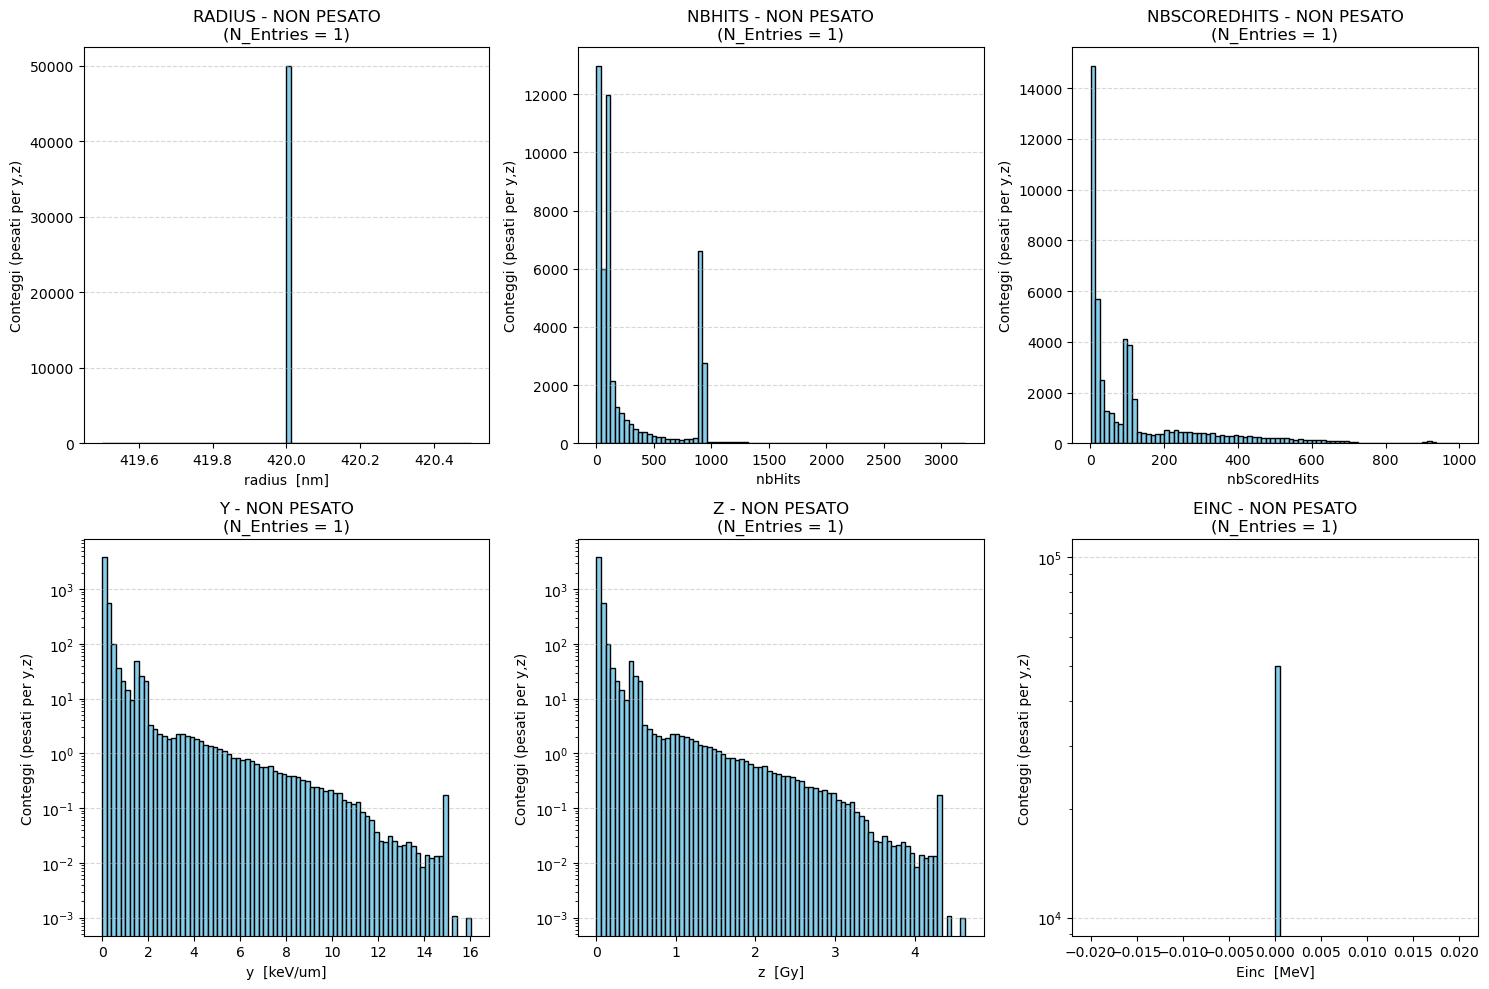

In [185]:
import matplotlib.pyplot as plt
import numpy as np

# 1. CALCOLO PESI (Una sola volta)
# Se nbScoredHits è > 0, il peso è 1/nbScoredHits, altrimenti è 0
df['weight'] = 1.0 / df['nbScoredHits']

# 2. DEFINIZIONE DELLE COLONNE E RANGE (Puoi personalizzare i range qui)
cols_to_plot = ['radius', 'nbHits', 'nbScoredHits', 'y', 'z', 'Einc']

# 3. PLOTTING
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    current_range = custom_ranges.get(col)
    print(f" Istogramma {col} ha un range impostato a: {current_range}")
    # Applichiamo il peso SOLO se la colonna è 'y' o 'z'
    current_weights = df['weight'] if col in ['y', 'z'] else None
    
    # Decidiamo la scala logaritmica (opzionale, basato sui tuoi dati)
    is_log = col in ['y', 'z', 'Einc']
    
    # Plot dell'istogramma
    axes[i].hist(df[col], bins=80, range=custom_ranges.get(col), 
                 color='skyblue', edgecolor='black', log=is_log, 
                 weights=current_weights)
    
    axes[i].set_title(f'{col.upper()} - NON PESATO\n(N_Entries = {count})')
    axes[i].set_xlabel(f'{col} {units.get(col, "")}')
    axes[i].set_ylabel('Conteggi (pesati per y,z)')
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

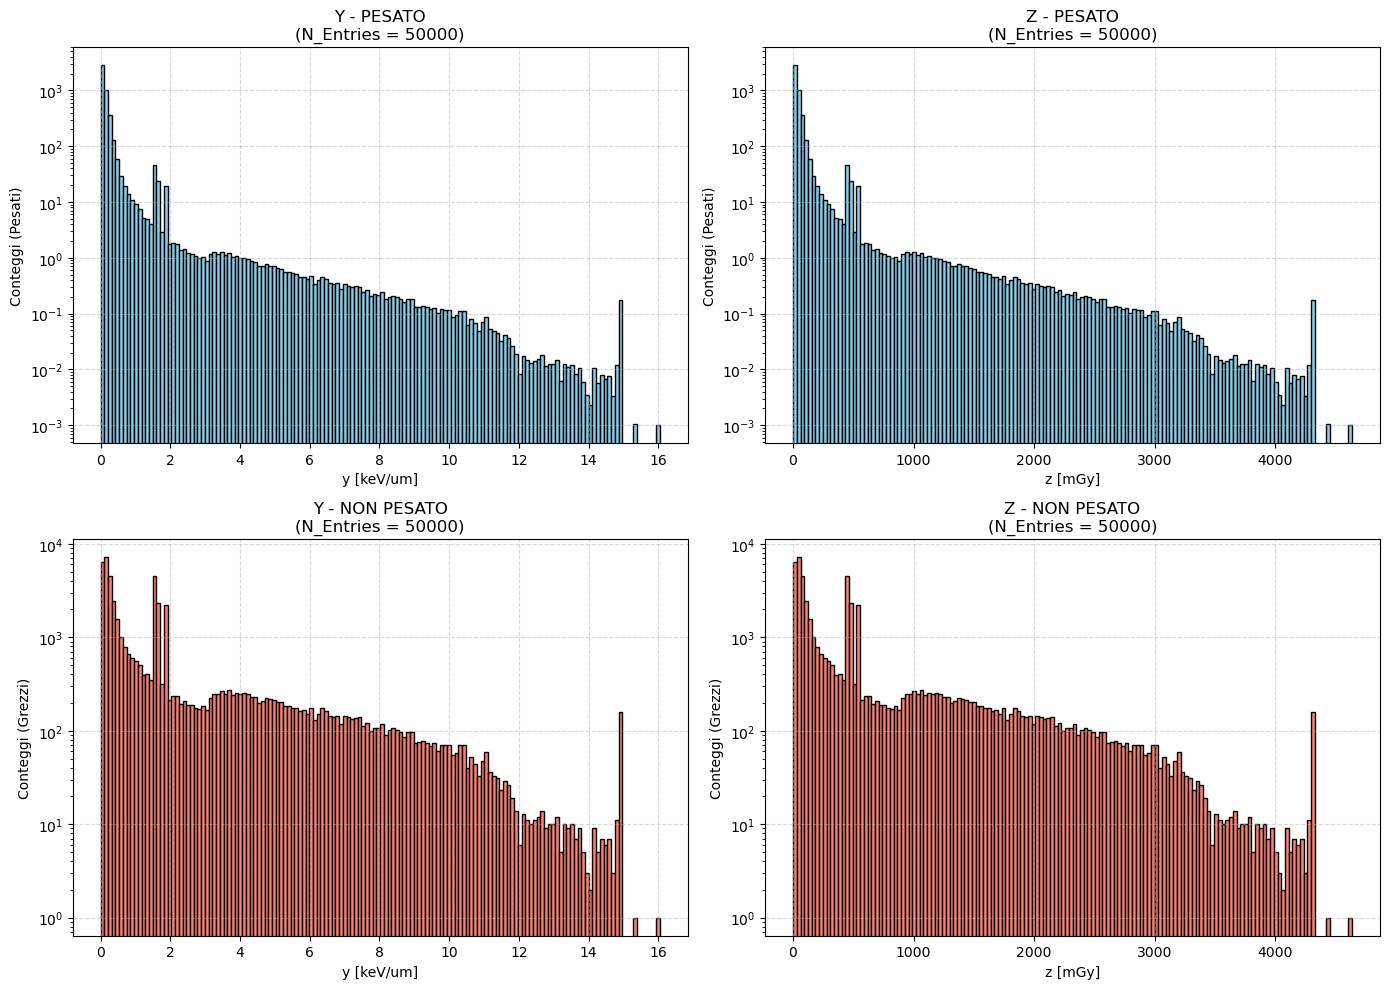

In [186]:
import matplotlib.pyplot as plt
import numpy as np

# Fattori di conversione
scales = {'y': 1.0, 'z': 1000.0}
units_label = {'y': 'keV/um', 'z': 'mGy'}

# Creiamo la figura
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))

# Definiamo le colonne
cols = ['y', 'z']

for i, col in enumerate(cols):
    data = df[col] * scales[col]
    
    # Calcolo conteggi
    # Per il non pesato: numero puro di eventi
    count = len(df)
    
    # 1. GRAFICO PESATO (Corretto)
    axes[0, i].hist(data, bins=150, range=None, weights=df['weight'], 
                    color='skyblue', edgecolor='black', log=True)
    axes[0, i].set_title(f'{col.upper()} - PESATO\n(N_Entries = {count:.0f})')
    axes[0, i].set_ylabel('Conteggi (Pesati)')
    axes[0, i].set_xlabel(f'{col} [{units_label[col]}]')
    axes[0, i].grid(linestyle='--', alpha=0.5)

    # 2. GRAFICO NON PESATO (Grezzo)
    axes[1, i].hist(data, bins=150, range=None, weights=None, 
                    color='salmon', edgecolor='black', log=True)
    axes[1, i].set_title(f'{col.upper()} - NON PESATO\n(N_Entries = {count})')
    axes[1, i].set_ylabel('Conteggi (Grezzi)')
    axes[1, i].set_xlabel(f'{col} [{units_label[col]}]')
    axes[1, i].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Step 2
Entriamo nello specifico della lineal energy, y, e della specific energy, z.

Calcoliamo $y_F$ e $z_F$.

In [187]:
# Filtriamo i dati per evitare divisioni per zero o valori non fisici
y_data = df[df['y'] > 0]['y']

# 1. Media in frequenza (y_F)
y_f = y_data.mean()

# 2. Media in dose (y_D)
# Formula: somma(y^2) / somma(y)
y_d = (y_data**2).sum() / y_data.sum()

# 3. Varianza e Deviazione Standard (della distribuzione in frequenza)
y_var = y_data.var()
y_std = y_data.std()

print(f"Media in frequenza: {y_f:.4f} keV/µm")
print(f"Media in dose: {y_d:.4f} keV/µm")
print(f"Deviazione standard: {y_std:.4f} keV/µm")
print(f"Numero di eventi considerati: {len(y_data)}")

Media in frequenza: 2.0367 keV/µm
Media in dose: 5.7073 keV/µm
Deviazione standard: 2.7342 keV/µm
Numero di eventi considerati: 50000


### Step 3
Intera pipeline dalle quantità microdosimetriche a MKM e LQ model.

In [188]:
R_d=0.420
R_n=4
y0=150
alpha_0 = 0.147 #Per v79 [Gy^-1]
beta_cell = 0.02   #Per v79 [Gy^-2]

In [ ]:
z_data = df[df['z'] > 0]['z'].to_numpy()
y_data = df[df['y'] > 0]['y'].to_numpy()
casi_eventi = 20000
k_conv = 1.2015 / massa_kg
d_per_hit = np.mean(z_data) * k_conv
D_n = casi_eventi * d_per_hit
S_n = np.exp(-alpha_0 * D_n - beta_cell * (D_n**2))

plt.plot(casi_eventi, S_n)
plt.yscale('log')
plt.show()

α_cell: 0.1472 Gy^-1


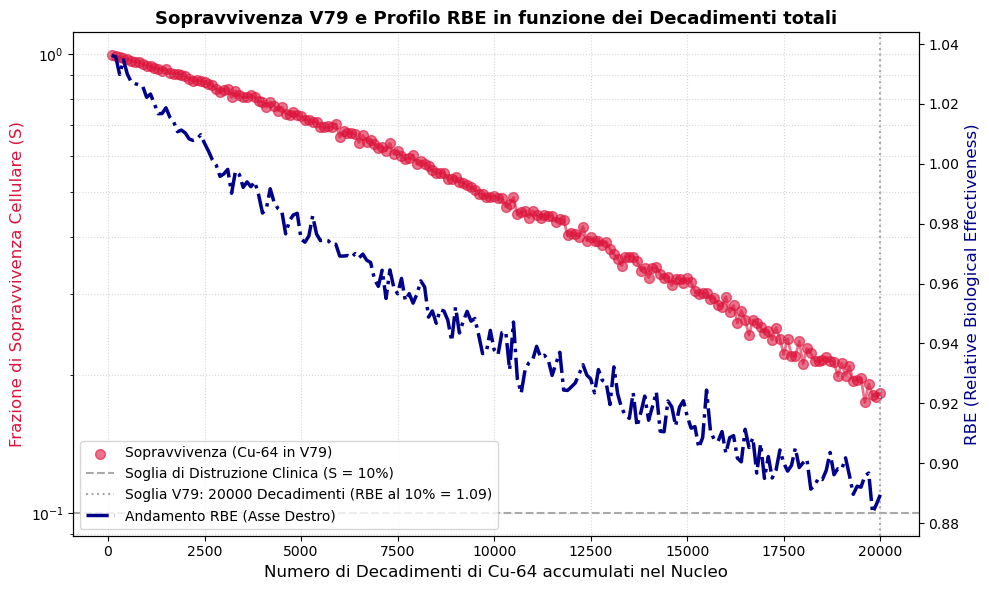

In [ ]:
# 1. PARAMETRI E CALCOLO FATTORE GEOMETRICO
# Nota: R_d deve essere in micrometri (um) per coerenza con le unità tipiche di G4-DNA
# Massa del dominio sferico in kg (densità 1 g/cm^3 = 1e-15 kg/um^3)
rho = 1e-15 
volume_um3 = (4/3) * np.pi * (R_d**3)
massa_kg = rho * volume_um3
# Conversione: (1.602e-16 J/keV) / massa_kg
k_conv = 1.2015 / massa_kg

rng = np.random.default_rng()

# 2. ELABORAZIONE DATI (Peso in dose)
# z_data contiene già l'energia specifica depositata nei domini da G4-DNA
z_data = df[df['z'] > 0]['z'].to_numpy()
y_data = df[df['y'] > 0]['y'].to_numpy()

# Calcolo y* (media pesata in dose)
# Usiamo la definizione standard: sum(y^2 * f(y)) / sum(y * f(y))
y_star = np.sum((y_data**2) * (1 - np.exp(-(y_data**2) / (y0**2)))) / np.sum(y_data)

alpha_cell = alpha_0 + (beta_cell * k_conv * y_star)
print(f"α_cell: {alpha_cell:.4f} Gy^-1")

# 3. PIPELINE MULTI-CASO CON BOOTSTRAP
casi_eventi = np.linspace(100, 20000, 200) 
risultati_sopravvivenza = []
dosi_medie_nucleo = []

for N in casi_eventi:
    # 1. Quanti decadimenti colpiscono effettivamente il dominio?
    # Usiamo p_colpito per filtrare il numero di eventi fisici (decadimenti -> hit)
    N_hit = rng.binomial(n=int(N), p=p_colpito, size=tentativi_bootstrap)
    
    # 2. Calcolo dose stocastica per ogni tentativo
    dosi_stocastiche = []
    for n in N_hit:
        if n > 0:
            # Campiona n energie e somma
            energia_tot = np.sum(rng.choice(z_data, size=n, replace=True))
            dosi_stocastiche.append(energia_tot * k_conv)
        else:
            dosi_stocastiche.append(0.0)
    
    dosi_stocastiche = np.array(dosi_stocastiche)
    
    # 3. Modello LQ
    S_tentativi = np.exp(-alpha_cell * dosi_stocastiche - beta_cell * (dosi_stocastiche**2))
    
    risultati_sopravvivenza.append(np.mean(S_tentativi))
    dosi_medie_nucleo.append(np.mean(dosi_stocastiche))

# 4. ANALISI SOGLIA
soglia_biologica = 0.10
S_array = np.array(risultati_sopravvivenza)
# Protezione per log
S_protetto = np.clip(S_array, 1e-20, 1.0)
log_S_rev = np.log(S_protetto[::-1])
casi_rev = casi_eventi[::-1]
decadimenti_soglia = np.interp(np.log(soglia_biologica), log_S_rev, casi_rev)

# Calcolo RBE al 10%
dose_soglia_sim = np.interp(np.log(soglia_biologica), log_S_rev, np.array(dosi_medie_nucleo)[::-1])
dose_soglia_ref = (-alpha_0 + np.sqrt(alpha_0**2 - 4 * beta_cell * np.log(soglia_biologica))) / (2 * beta_cell)
rbe_al_10 = dose_soglia_ref / dose_soglia_sim


# 5. GRAFICO FINALE A DOPPIO ASSE: SOPRAVVIVENZA CELLULARE + CURVA RBE
fig, ax1 = plt.subplots(figsize=(10, 6))

# ASSE SINISTRO: Frazione di Sopravvivenza (S)
color_s = 'crimson'
ax1.scatter(casi_eventi, risultati_sopravvivenza, color=color_s, s=50, alpha=0.6, label='Sopravvivenza (Cu-64 in V79)')
ax1.plot(casi_eventi, risultati_sopravvivenza, color=color_s, linestyle='-', alpha=0.6, linewidth=2)
ax1.set_yscale('log')
ax1.set_xlabel("Numero di Decadimenti di Cu-64 accumulati nel Nucleo", fontsize=12)
ax1.set_ylabel("Frazione di Sopravvivenza Cellulare (S)", color=color_s, fontsize=12)
ax1.grid(True, which="both", linestyle=":", alpha=0.5)

# ASSE DESTRO: RBE variabile
ax2 = ax1.twinx()
color_rbe = 'darkblue'
S_protetto = np.clip(risultati_sopravvivenza, 1e-20, 1.0) # Proteggo per non avere log(0) o valori negativij
dosi_ref_casi = (-alpha_0 + np.sqrt(alpha_0**2 - 4 * beta_cell * np.log(S_protetto))) / (2 * beta_cell)
rbe_casi = dosi_ref_casi / np.array(dosi_medie_nucleo)
ax2.plot(casi_eventi, rbe_casi, color=color_rbe, linestyle='-.', linewidth=2.5, label='Andamento RBE (Asse Destro)')
ax2.set_ylabel("RBE (Relative Biological Effectiveness)", color=color_rbe, fontsize=12)

# --- SOGLIE BIOLOGICHE E VERTICALI ---
line_soglia = ax1.axhline(y=soglia_biologica, color='darkgray', linestyle='--', linewidth=1.5, 
                         label=f'Soglia di Distruzione Clinica (S = {int(soglia_biologica*100)}%)')

line_vert = ax1.axvline(x=decadimenti_soglia, color='darkgray', linestyle=':', linewidth=1.5,
                        label=f'Soglia V79: {int(np.ceil(decadimenti_soglia))} Decadimenti (RBE al 10% = {rbe_al_10:.2f})')

# UNIONE DELLE LEGENDE (Fondamentale per avere tutto in un unico box)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='lower left')

plt.title("Sopravvivenza V79 e Profilo RBE in funzione dei Decadimenti totali", fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()


Qui vado solo a "migliorare" la visibilità del plot.

  Caso (N) |   Dose Nucleo [Gy] |   Sopravvivenza |  RBE Teorico
-----------------------------------------------------------------
       100 |             0.0647 |      9.7977e-01 |         2.73
       506 |             0.3502 |      8.9663e-01 |         2.53
       912 |             0.6372 |      8.1410e-01 |         2.38
      1318 |             0.8939 |      7.4435e-01 |         2.28
      1724 |             1.1728 |      6.8414e-01 |         2.19
      2130 |             1.4061 |      6.3004e-01 |         2.12
      2536 |             1.6677 |      5.7781e-01 |         2.06
      2942 |             1.9712 |      5.2380e-01 |         1.99
      3348 |             2.4138 |      4.5924e-01 |         1.91
      3755 |             2.3522 |      4.5140e-01 |         1.92
      4161 |             2.9261 |      3.6454e-01 |         1.84
      4567 |             3.1219 |      3.4907e-01 |         1.82
      4973 |             3.3857 |      3.2014e-01 |         1.78
      5379 |            

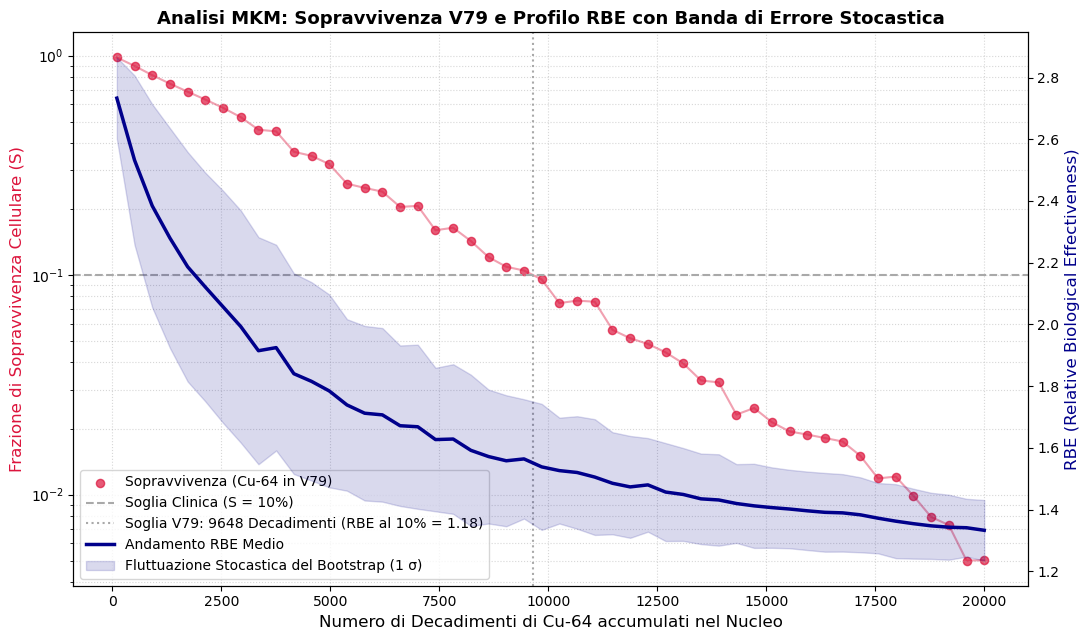

In [190]:
# ==============================================================================
# PROGETTO NUOVO: MODELLO MKM CON INCERTEZZA STOCASTICA DEL BOOTSTRAP
# ==============================================================================

# [NOTA]: Assicurati che le variabili R_d, R_n, y0, alpha_0, beta_cell e il 
# dataframe 'df' siano già caricati in memoria prima di eseguire questo script.

# 1. INIZIALIZZAZIONE PARAMETRI FISICI E GEOMETRICI
k_conv = 0.12015 / R_d
rapporto_volumi = (R_d / R_n)**3 
p_colpito = rapporto_volumi  # Probabilità geometrica di colpire il dominio
rng = np.random.default_rng(seed=42)  # Seed fisso per riproducibilità statistica

# 2. ESTRATTORI DATI MICRODOSIMETRICI
y_data = df[df['y'] > 0]['y'].to_numpy()
z_data = df[df['z'] > 0]['z'].to_numpy()

# Calcolo y* pesato correttamente sulla distribuzione discreta in dose d(y)
y_numerator = np.sum(((y0**2) * (1 - np.exp(-(y_data**2) / (y0**2)))) * y_data)
y_denominator = np.sum(y_data)
y_star = y_numerator / y_denominator

# Calcolo del parametro alpha biologico cellulare (MKM)
alpha_cell = alpha_0 + (beta_cell * k_conv * y_star)

# 3. PIPELINE DI SIMULAZIONE MULTI-CASO (Range esteso a 20.000 eventi)
casi_eventi = np.linspace(100, 20000, 50)  # 50 step per una curva fluida

risultati_sopravvivenza = []
dosi_medie_nucleo = []
rbe_medi_analitici = []
rbe_deviazioni_std = []  # Salverà l'incertezza dovuta alla stocasticità

print(f"{'Caso (N)':>10} | {'Dose Nucleo [Gy]':>18} | {'Sopravvivenza':>15} | {'RBE Teorico':>12}")
print("-" * 65)

for N in casi_eventi:
    tentativi_bootstrap = 500
    sopravvivenze_tentativi = []
    dosi_tentativi = []
    rbe_tentativi = []
    
    for _ in range(tentativi_bootstrap):
        # Il bootstrap simula che ogni step pesca eventi diversi dal paniere
        N_dominio = rng.binomial(n=int(N), p=p_colpito)
        
        if N_dominio > 0:
            sample_z = rng.choice(z_data, size=N_dominio, replace=True)
            D_locale = sample_z.sum()
        else:
            D_locale = 0.0
            
        # Calcolo stocastico della sopravvivenza per questa "fittizia" cellula
        S_stoch = np.exp(-alpha_cell * D_locale - beta_cell * (D_locale**2))
        
        # Calcolo dell'RBE associato a questa specifica estrazione stocastica
        if D_locale > 0:
            D_ref_stoch = (-alpha_0 + np.sqrt(alpha_0**2 - 4 * beta_cell * np.log(S_stoch))) / (2 * beta_cell)
            rbe_singolo = D_ref_stoch / D_locale
        else:
            rbe_singolo = alpha_cell / alpha_0
            
        sopravvivenze_tentativi.append(S_stoch)
        dosi_tentativi.append(D_locale)
        rbe_tentativi.append(rbe_singolo)
        
    # Calcolo dei valori medi reali risultanti dalla simulazione
    S_media = np.mean(sopravvivenze_tentativi)
    D_media = np.mean(dosi_tentativi)
    
    # RBE macroscopico stabile basato sul trend medio del modello
    if D_media > 0:
        rbe_punto_medio = (np.sqrt(alpha_0**2 + 4 * beta_cell * (alpha_cell * D_media + beta_cell * (D_media**2))) - alpha_0) / (2 * beta_cell * D_media)
    else:
        rbe_punto_medio = alpha_cell / alpha_0
        
    risultati_sopravvivenza.append(S_media)
    dosi_medie_nucleo.append(D_media)
    rbe_medi_analitici.append(rbe_punto_medio)
    
    # Registriamo la deviazione standard reale generata dal rimescolamento degli eventi
    rbe_deviazioni_std.append(np.std(rbe_tentativi))
    
    print(f"{int(N):10d} | {D_media:18.4f} | {S_media:15.4e} | {rbe_punto_medio:12.2f}")

# 4. DETERMINAZIONE DELLA SOGLIA CLINICA AL 10%
soglia_biologica = 0.10
log_S_rev = np.log(np.array(risultati_sopravvivenza)[::-1])
casi_rev = casi_eventi[::-1]
decadimenti_soglia = np.interp(np.log(soglia_biologica), log_S_rev, casi_rev)

dosi_nucleo_array = np.array(dosi_medie_nucleo)
dose_soglia_sim = np.interp(np.log(soglia_biologica), log_S_rev, dosi_nucleo_array[::-1])
dose_soglia_ref = (-alpha_0 + np.sqrt(alpha_0**2 - 4 * beta_cell * np.log(soglia_biologica))) / (2 * beta_cell)
rbe_al_10 = dose_soglia_ref / dose_soglia_sim

# ==============================================================================
# 5. GENERAZIONE GRAFICO AD ALTA RISOLUZIONE (CON BANDA SFUMATA)
# ==============================================================================
fig, ax1 = plt.subplots(figsize=(11, 6.5))

# ASSE SINISTRO: Sopravvivenza Cellulare (S)
color_s = 'crimson'
ax1.scatter(casi_eventi, risultati_sopravvivenza, color=color_s, s=35, alpha=0.7, label='Sopravvivenza (Cu-64 in V79)')
ax1.plot(casi_eventi, risultati_sopravvivenza, color=color_s, linestyle='-', alpha=0.4, linewidth=1.5)
ax1.set_yscale('log')
ax1.set_xlabel("Numero di Decadimenti di Cu-64 accumulati nel Nucleo", fontsize=12)
ax1.set_ylabel("Frazione di Sopravvivenza Cellulare (S)", color=color_s, fontsize=12)
ax1.grid(True, which="both", linestyle=":", alpha=0.5)

# ASSE DESTRO: Andamento RBE e Banda di Incertezza Statistici
ax2 = ax1.twinx()
color_rbe = 'darkblue'

rbe_medi_analitici = np.array(rbe_medi_analitici)
rbe_deviazioni_std = np.array(rbe_deviazioni_std)

# Costruzione dei confini geometrici della banda d'errore (±1 Deviazione Standard)
rbe_limite_superiore = rbe_medi_analitici + rbe_deviazioni_std
rbe_limite_inferiore = rbe_medi_analitici - rbe_deviazioni_std

# Disegno della curva di RBE media (pulita) e dell'ombra di incertezza
ax2.plot(casi_eventi, rbe_medi_analitici, color=color_rbe, linestyle='-', linewidth=2.5, label='Andamento RBE Medio')
ax2.fill_between(casi_eventi, rbe_limite_inferiore, rbe_limite_superiore, color=color_rbe, alpha=0.15, 
                 label='Fluttuazione Stocastica del Bootstrap (1 σ)')
ax2.set_ylabel("RBE (Relative Biological Effectiveness)", color=color_rbe, fontsize=12)

# --- LINEE DI SOGLIA CLINICA ED INTERSEZIONI ---
line_soglia = ax1.axhline(y=soglia_biologica, color='darkgray', linestyle='--', linewidth=1.5, 
                         label=f'Soglia Clinica (S = {int(soglia_biologica*100)}%)')

line_vert = ax1.axvline(x=decadimenti_soglia, color='darkgray', linestyle=':', linewidth=1.5,
                        label=f'Soglia V79: {int(np.ceil(decadimenti_soglia))} Decadimenti (RBE al 10% = {rbe_al_10:.2f})')

# UNIFICAZIONE DEL BOX DELLE LEGENDE
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10, loc='lower left')

plt.title("Analisi MKM: Sopravvivenza V79 e Profilo RBE con Banda di Errore Stocastica", fontsize=13, fontweight='bold')
fig.tight_layout()
plt.show()


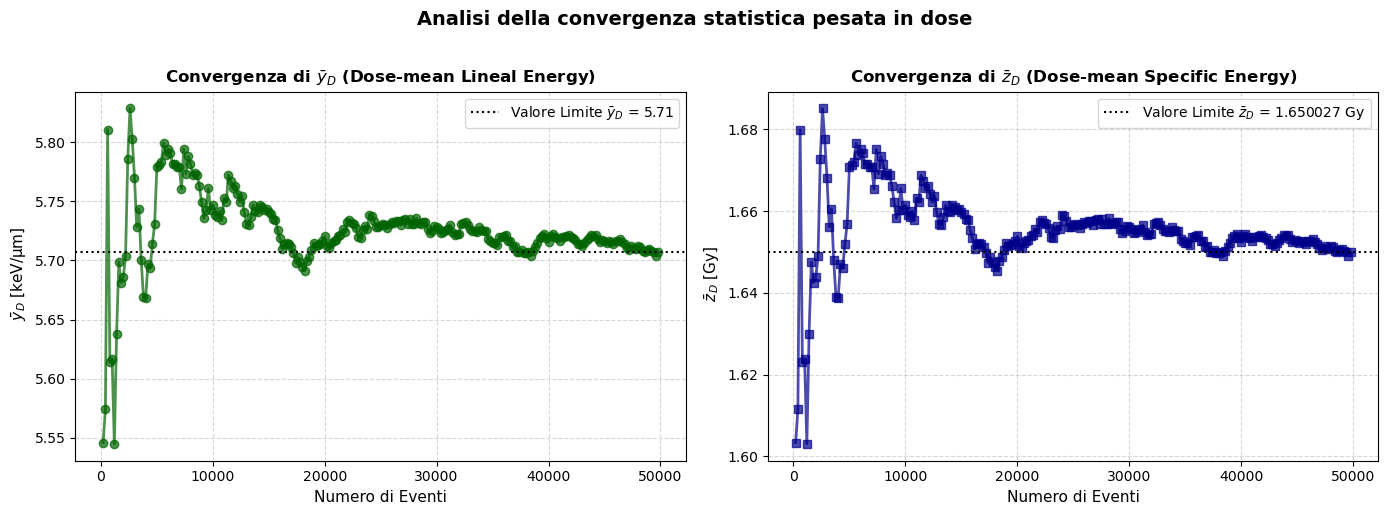

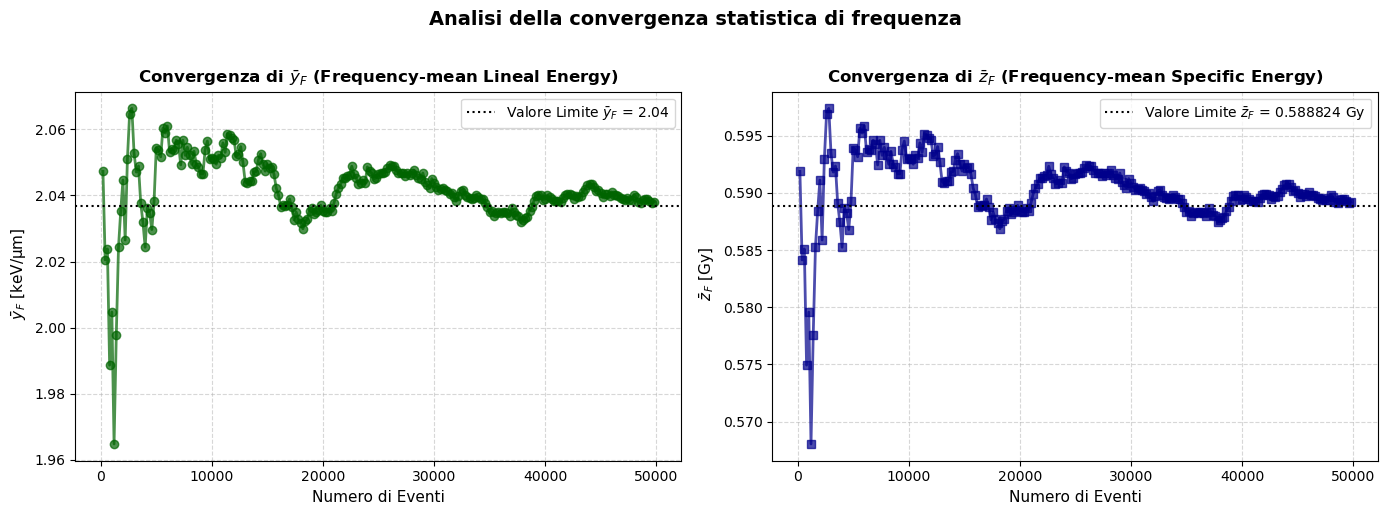

In [191]:
# ==============================================================================
# STUDIO DELLA CONVERGENZA STATISTICA DI y_D E z_D (PESATI IN DOSE)
# ==============================================================================
# Partiamo da un numero minimo di eventi (es. 'step') per evitare divisioni per zero all'inizio
step = 200
step_statistica = np.arange(step, len(y_data), step) 

y_f_cumulativi = []
z_f_cumulativi = []

y_d_cumulativi = []
z_d_cumulativi = []

# Calcoliamo i valori "di riferimento" (limiti) sull'intero dataset per le linee orizzontali
#y_f e z_f
ref_y_f = np.mean(y_data)
ref_z_f = np.mean(z_data)
#y_d e z_d
ref_y_d = np.sum(y_data**2) / np.sum(y_data)
ref_z_d = np.sum(z_data**2) / np.sum(z_data)

for n_eventi in step_statistica:
    # Estraiamo i sottogruppi
    y_sub = y_data[:n_eventi]
    z_sub = z_data[:n_eventi]
    
    # Calcolo della media pesata in dose (Dose-mean)
    # Formula: sum(x^2) / sum(x)
    y_f_cumulativi.append(np.mean(y_sub))
    z_f_cumulativi.append(np.mean(z_sub))
    y_d_cumulativi.append(np.sum(y_sub**2) / np.sum(y_sub))
    z_d_cumulativi.append(np.sum(z_sub**2) / np.sum(z_sub))

# Convertiamo in array
y_f_cumulativi = np.array(y_f_cumulativi)
z_f_cumulativi = np.array(z_f_cumulativi)

y_d_cumulativi = np.array(y_d_cumulativi)
z_d_cumulativi = np.array(z_d_cumulativi)

# --- GENERAZIONE DEL GRAFICO DI CONVERGENZA PESATA ---
fig, (ax_y, ax_z) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot per y_D
ax_y.plot(step_statistica, y_d_cumulativi, marker='o', color='darkgreen', linewidth=2, linestyle='-', alpha=0.7)
ax_y.axhline(y=ref_y_d, color='black', linestyle=':', label=f'Valore Limite $\\bar{{y}}_D$ = {ref_y_d:.2f}')
ax_y.set_xlabel("Numero di Eventi", fontsize=11)
ax_y.set_ylabel(r" $\bar{y}_D$ [keV/µm]", fontsize=11)
ax_y.set_title(r"Convergenza di $\bar{y}_D$ (Dose-mean Lineal Energy)", fontsize=12, fontweight='bold')
ax_y.grid(True, linestyle='--', alpha=0.5)
ax_y.legend()

# 2. Plot per z_D
ax_z.plot(step_statistica, z_d_cumulativi, marker='s', color='darkblue', linewidth=2, linestyle='-', alpha=0.7)
ax_z.axhline(y=ref_z_d, color='black', linestyle=':', label=f'Valore Limite $\\bar{{z}}_D$ = {ref_z_d:.6f} Gy')
ax_z.set_xlabel("Numero di Eventi", fontsize=11)
ax_z.set_ylabel(r" $\bar{z}_D$ [Gy]", fontsize=11)
ax_z.set_title(r"Convergenza di $\bar{z}_D$ (Dose-mean Specific Energy)", fontsize=12, fontweight='bold')
ax_z.grid(True, linestyle='--', alpha=0.5)
ax_z.legend()

plt.suptitle("Analisi della convergenza statistica pesata in dose", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# --- GENERAZIONE DEL GRAFICO DI CONVERGENZA NON PESATA ---
fig, (ax_y, ax_z) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Plot per y_F
ax_y.plot(step_statistica, y_f_cumulativi, marker='o', color='darkgreen', linewidth=2, linestyle='-', alpha=0.7)
ax_y.axhline(y=ref_y_f, color='black', linestyle=':', label=f'Valore Limite $\\bar{{y}}_F$ = {ref_y_f:.2f}')
ax_y.set_xlabel("Numero di Eventi", fontsize=11)
ax_y.set_ylabel(r" $\bar{y}_F$ [keV/µm]", fontsize=11)
ax_y.set_title(r"Convergenza di $\bar{y}_F$ (Frequency-mean Lineal Energy)", fontsize=12, fontweight='bold')
ax_y.grid(True, linestyle='--', alpha=0.5)
ax_y.legend()

# 2. Plot per z_F
ax_z.plot(step_statistica, z_f_cumulativi, marker='s', color='darkblue', linewidth=2, linestyle='-', alpha=0.7)
ax_z.axhline(y=ref_z_f, color='black', linestyle=':', label=f'Valore Limite $\\bar{{z}}_F$ = {ref_z_f:.6f} Gy')
ax_z.set_xlabel("Numero di Eventi", fontsize=11)
ax_z.set_ylabel(r" $\bar{z}_F$ [Gy]", fontsize=11)
ax_z.set_title(r"Convergenza di $\bar{z}_F$ (Frequency-mean Specific Energy)", fontsize=12, fontweight='bold')
ax_z.grid(True, linestyle='--', alpha=0.5)
ax_z.legend()

plt.suptitle("Analisi della convergenza statistica di frequenza", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
